In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math
import numpy as np
from IPython.display import display

df1 = pd.read_csv('bigmerge_cleaned2.csv')
realTs = df1[df1['spectral_temperature'] > 0].copy()
master = df1[(df1['fit_points'] > 99) & (df1['spectral_temperature'] > 0) & (df1['gain'] > 9.9)& (df1['gain'] < 10.1)].copy()
#display(df1)
#display(realTs)
#display(master)


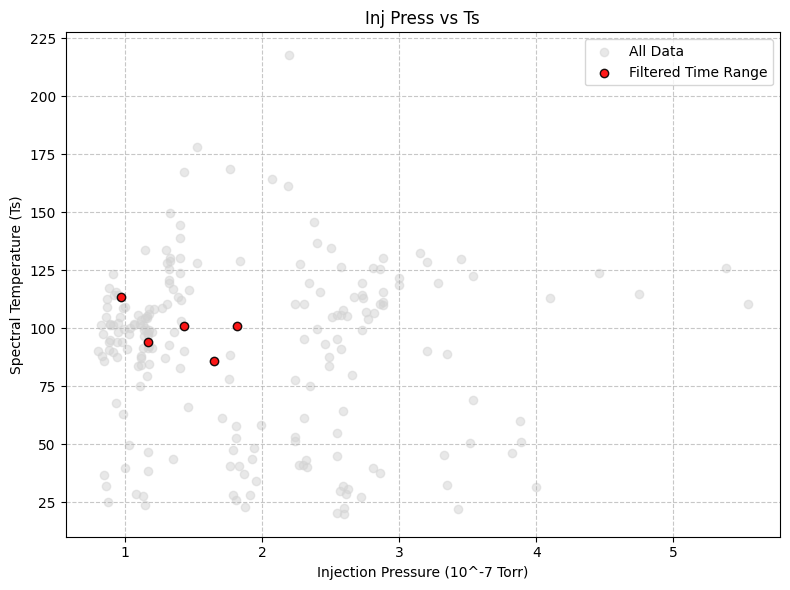

Plot successfully generated with 5 highlighted points.


In [ ]:
#Injection Pressure vs Ts

# Ensure the datetime column is properly formatted
realTs['datetime'] = pd.to_datetime(realTs['datetime'])

# Define your strict time boundaries
start_time = pd.to_datetime('2025-05-20 03:20:00')
end_time = pd.to_datetime('2025-05-20 03:50:00')

# 1. Filter by the specified date and time window
df_filtered = realTs[(realTs['datetime'] >= start_time) & (realTs['datetime'] <= end_time)]

# 2. Drop rows missing the required data for this specific plot
df_plot = df_filtered.dropna(subset=['spectral_temperature', 'Inj Pres (-7)']).copy()

# 5. Generate the Plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # PLOT 1 (BACKGROUND): All Data
    # Plotted first with a low zorder, 'lightgray' color, and lower alpha (transparency) so it doesn't overwhelm the foreground
    plt.scatter(realTs['Inj Pres (-7)'], realTs['spectral_temperature'], 
                color='lightgray', alpha=0.5, label='All Data', zorder=1)
    
    # PLOT 2 (FOREGROUND): Filtered Time Range
    # Plotted second with a higher zorder and distinct color to make it pop
    plt.scatter(df_plot['Inj Pres (-7)'], df_plot['spectral_temperature'], 
                color='red', edgecolor='k', alpha=0.9, label='Filtered Time Range', zorder=2)
    
    plt.xlabel('Injection Pressure (10^-7 Torr)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Inj Press vs Ts')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add a legend so viewers know what the gray vs red dots mean
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_plot)} highlighted points.")
else:
    print("No valid data points found in this time range.")

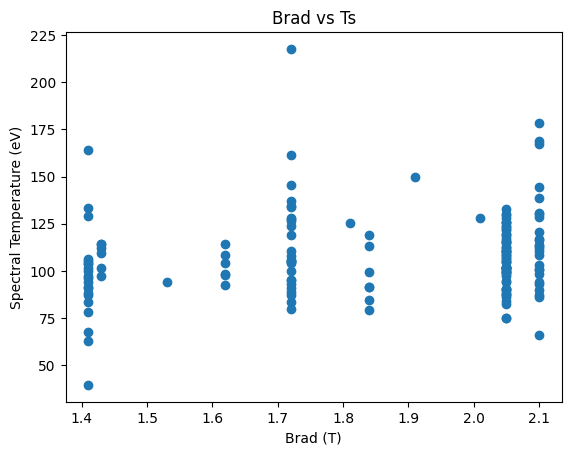

In [98]:
plt.scatter(master['Sext (T)'], master['spectral_temperature'])
plt.xlabel('Brad (T)')
plt.ylabel('Spectral Temperature (eV)')
plt.title('Brad vs Ts')
plt.show()

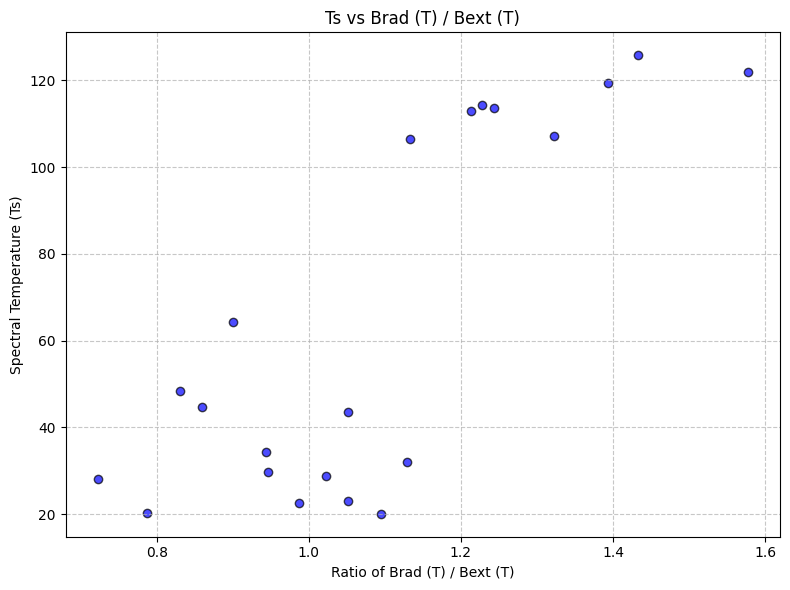

Plot successfully generated with 21 points.


In [ ]:
#Ts vs Brad / Bext =  positive correlation (kind of)

# Ensure the datetime column is properly formatted
realTs['datetime'] = pd.to_datetime(realTs['datetime'])

# Define your strict time boundaries
start_time = pd.to_datetime('2025-10-14 15:00:00')
end_time = pd.to_datetime('2025-10-15 12:00:00')

# 1. Filter by the specified date and time window
df_filtered = realTs[(realTs['datetime'] >= start_time) & (realTs['datetime'] <= end_time)]

# 2. Drop rows missing the required data for this specific plot
df_plot = df_filtered.dropna(subset=['spectral_temperature', 'Sext (T)', 'Extr (T)'])

# 3. Prevent division-by-zero errors in case Extr (T) is exactly 0
df_plot = df_plot[df_plot['Extr (T)'] != 0]

# 4. Calculate the ratio
df_plot['Sext_Extr_Ratio'] = df_plot['Sext (T)'] / df_plot['Extr (T)']

# 5. Generate the Plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    plt.scatter(df_plot['Sext_Extr_Ratio'], df_plot['spectral_temperature'], 
                c='blue', alpha=0.7, edgecolor='k')
    
    plt.xlabel('Ratio of Brad (T) / Bext (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs Brad (T) / Bext (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found in this time range.")

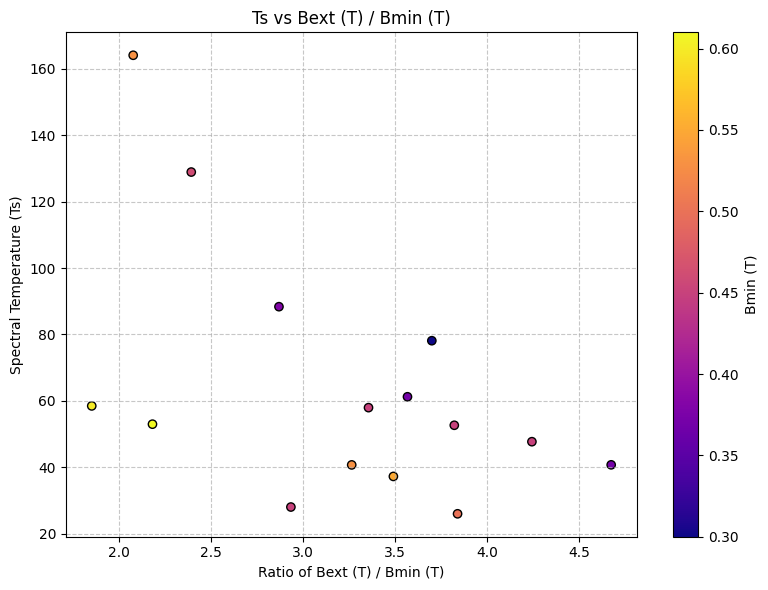

Plot successfully generated with 15 points.


In [ ]:
#Ts vs Bext / Bmin

# Ensure the datetime column is properly formatted
realTs['datetime'] = pd.to_datetime(realTs['datetime'])

# Define your strict time boundaries
start_time = pd.to_datetime('2025-10-15 12:00:00')
end_time = pd.to_datetime('2025-10-15 16:10:00')

# 1. Filter by the specified date and time window
df_filtered = realTs[(realTs['datetime'] >= start_time) & (realTs['datetime'] <= end_time)]

# 2. Drop rows missing the required data for this specific plot
# Added .copy() to avoid SettingWithCopyWarning
df_plot = df_filtered.dropna(subset=['spectral_temperature', 'Extr (T)', 'Cent (T)']).copy()

# 3. Prevent division-by-zero errors in case Cent (T) is exactly 0
df_plot = df_plot[df_plot['Cent (T)'] != 0]

# 4. Calculate the ratio
df_plot['Extr_Cent_Ratio'] = df_plot['Extr (T)'] / df_plot['Cent (T)']

# 5. Generate the Plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # UPDATE: Set 'c' to the column data, add a colormap, and assign to a variable 'sc'
    sc = plt.scatter(df_plot['Extr_Cent_Ratio'], df_plot['spectral_temperature'], 
                     c=df_plot['Cent (T)'], cmap='plasma', edgecolor='k')
    
    plt.xlabel('Ratio of Bext (T) / Bmin (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs Bext (T) / Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # UPDATE: Add a colorbar to display the Bmin (T) scale
    plt.colorbar(sc, label='Bmin (T)')
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found in this time range.")

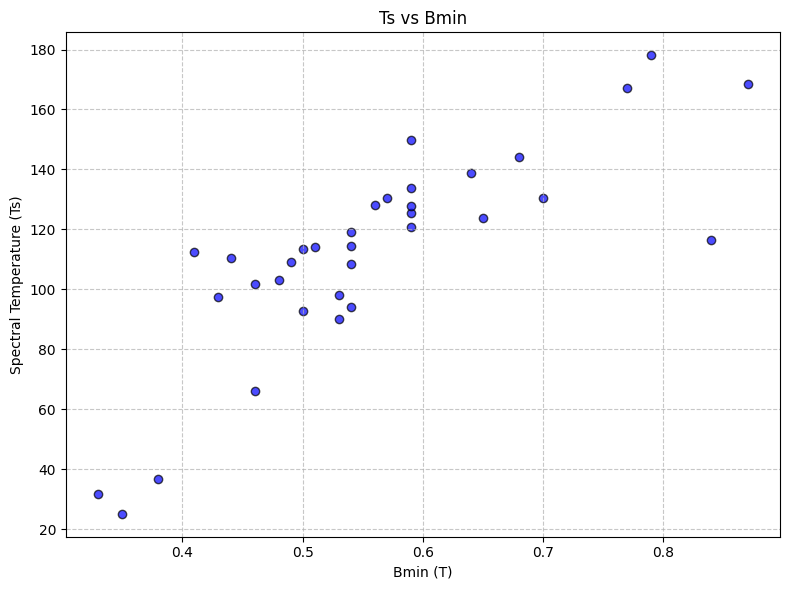

Plot successfully generated with 34 points.


In [ ]:
#Ts vs Bmin (all)

# Ensure the datetime column is properly formatted
realTs['datetime'] = pd.to_datetime(realTs['datetime'])

# Define your strict time boundaries
start_time = pd.to_datetime('2025-05-20 03:50:00')
end_time = pd.to_datetime('2025-05-21 07:10:00')

# 1. Filter by the specified date and time window
df_filtered = realTs[(realTs['datetime'] >= start_time) & (realTs['datetime'] <= end_time)]

# 2. Drop rows missing the required data for this specific plot
df_plot = df_filtered.dropna(subset=['spectral_temperature', 'Cent (T)'])

# 5. Generate the Plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    plt.scatter(df_plot['Cent (T)'], df_plot['spectral_temperature'], 
                c='blue', alpha=0.7, edgecolor='k')
    
    plt.xlabel('Bmin (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs Bmin')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found in this time range.")

Data points matching 28 only criteria: 54


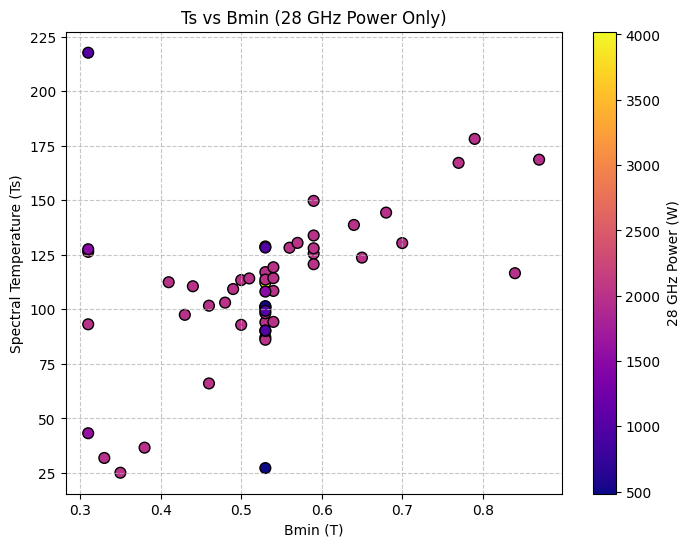

In [ ]:
#Ts vs Bmin (28 GHz Power Only)

# Drop any rows where we don't have Spectral Temperature or Bmin
df_plot = realTs.dropna(subset=['spectral_temperature', 'Cent (T)'])

# 2. Filter for ONLY 28 GHz active (assuming >100W means active)
cond_14 = df_plot['14 GHz'].isna() | (df_plot['14 GHz'] < 100)
cond_18 = df_plot['18 GHz'].isna() | (df_plot['18 GHz'] < 100)
cond_28 = df_plot['28 GHz'].notna() & (df_plot['28 GHz'] >= 100)

df_28only = df_plot[cond_14 & cond_18 & cond_28]

print(f"Data points matching 28 only criteria: {len(df_28only)}")

# 3. Generate the Plot
if len(df_28only) > 0:
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(df_28only['Cent (T)'], df_28only['spectral_temperature'], 
                     c=df_28only['28 GHz'], cmap='plasma', s=60, edgecolor='k')
    
    plt.xlabel('Bmin (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs Bmin (28 GHz Power Only)')
    plt.colorbar(sc, label='28 GHz Power (W)')
    plt.grid(True, linestyle='--', alpha=0.7)

else:
    print("No rows found where 28 GHz was the ONLY active power source.")

Data points matching 28 only criteria: 54


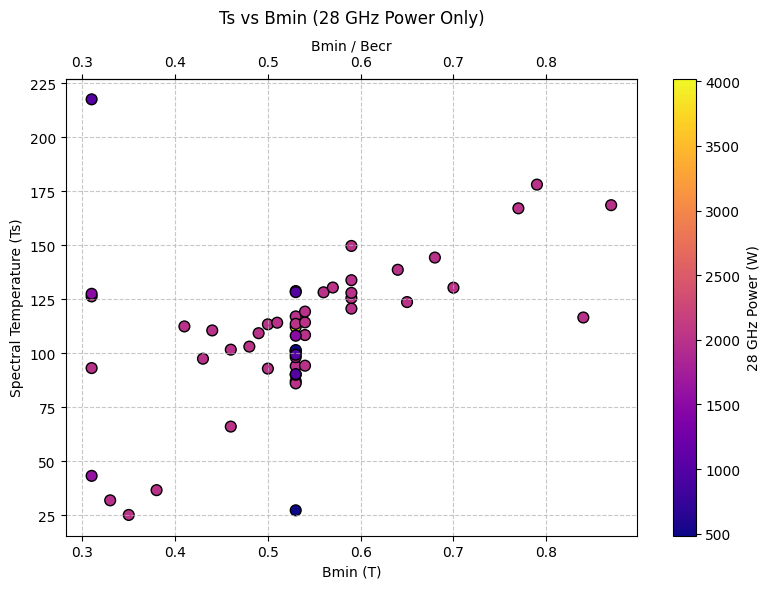

In [29]:
#Ts vs Bmin (28 GHz Power Only) with Becr (Jibo Li Comparison)

# Drop any rows where we don't have Spectral Temperature or Bmin
df_plot = realTs.dropna(subset=['spectral_temperature', 'Cent (T)'])

# 2. Filter for ONLY 28 GHz active (assuming >100W means active)
cond_14 = df_plot['14 GHz'].isna() | (df_plot['14 GHz'] < 100)
cond_18 = df_plot['18 GHz'].isna() | (df_plot['18 GHz'] < 100)
cond_28 = df_plot['28 GHz'].notna() & (df_plot['28 GHz'] >= 100)

df_28only = df_plot[cond_14 & cond_18 & cond_28]

print(f"Data points matching 28 only criteria: {len(df_28only)}")

# 3. Generate the Plot
if len(df_28only) > 0:
    # Use plt.subplots() to explicitly create an axes object ('ax') for the secondary axis
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sc = ax.scatter(df_28only['Cent (T)'], df_28only['spectral_temperature'], 
                     c=df_28only['28 GHz'], cmap='plasma', s=60, edgecolor='k')
    
    # Primary Axes Formatting
    ax.set_xlabel('Bmin (T)')
    ax.set_ylabel('Spectral Temperature (Ts)')
    
    # Add padding to the title so it doesn't overlap with the new top axis
    ax.set_title('Ts vs Bmin (28 GHz Power Only)', pad=40)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.colorbar(sc, label='28 GHz Power (W)', ax=ax)
    
    # --- NEW: Add Secondary X-Axis on Top ---
    Becr = 1.0 # 1 T for 28 GHz
    
    # Define how to convert back and forth between the two axes
    def bmin_to_ratio(x):
        return x / Becr
        
    def ratio_to_bmin(x):
        return x * Becr
        
    # Attach the secondary axis to the top
    secax = ax.secondary_xaxis('top', functions=(bmin_to_ratio, ratio_to_bmin))
    secax.set_xlabel('Bmin / Becr')
    
    plt.tight_layout()
    plt.show()

else:
    print("No rows found where 28 GHz was the ONLY active power source.")

Data points matching 18 GHz only criteria: 89


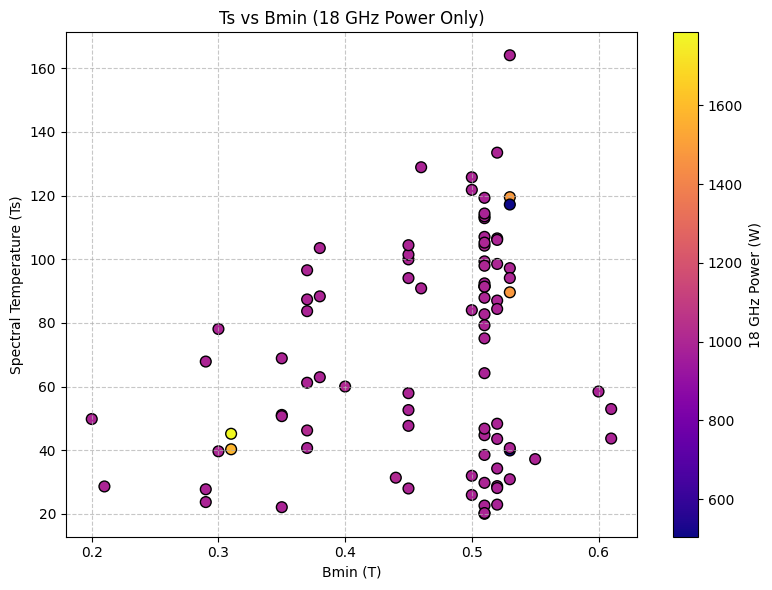

In [ ]:
# Ts vs Bmin (18 GHz Power Only)

# 1. Drop any rows where we don't have Spectral Temperature or Cent (T)
df_plot = realTs.dropna(subset=['spectral_temperature', 'Cent (T)'])

# 2. Filter for ONLY 18 GHz active (assuming >= 100W means active)
cond_14 = df_plot['14 GHz'].isna() | (df_plot['14 GHz'] < 100)
cond_18 = df_plot['18 GHz'].notna() & (df_plot['18 GHz'] >= 100)
cond_28 = df_plot['28 GHz'].isna() | (df_plot['28 GHz'] < 100)

df_18only = df_plot[cond_14 & cond_18 & cond_28]

print(f"Data points matching 18 GHz only criteria: {len(df_18only)}")

# 3. Generate the Plot
if len(df_18only) > 0:
    plt.figure(figsize=(8, 6))
    
    # Map the color to the 18 GHz column
    sc = plt.scatter(df_18only['Cent (T)'], df_18only['spectral_temperature'], 
                     c=df_18only['18 GHz'], cmap='plasma', s=60, edgecolor='k')
    
    plt.xlabel('Bmin (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs Bmin (18 GHz Power Only)')
    plt.colorbar(sc, label='18 GHz Power (W)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

else:
    print("No rows found where 18 GHz was the ONLY active power source.")

Data points matching 18 only criteria: 89


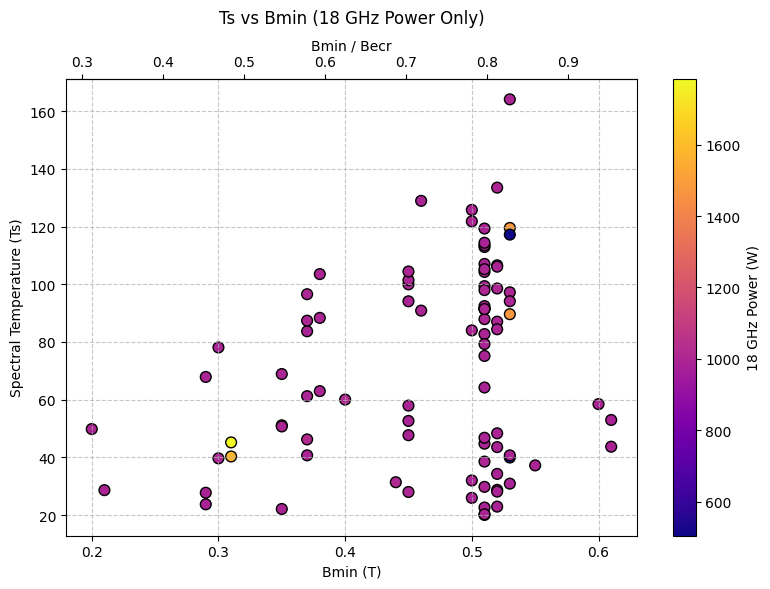

In [30]:
#Ts vs Bmin (18 GHz Power Only) with Becr (Jibo Li Comparison)

# Drop any rows where we don't have Spectral Temperature or Bmin
df_plot = realTs.dropna(subset=['spectral_temperature', 'Cent (T)'])

# 2. Filter for ONLY 18 GHz active (assuming >100W means active)
cond_14 = df_plot['14 GHz'].isna() | (df_plot['14 GHz'] < 100)
cond_18 = df_plot['18 GHz'].notna() & (df_plot['18 GHz'] >= 100)
cond_28 = df_plot['28 GHz'].isna() | (df_plot['28 GHz'] < 100)

df_18only = df_plot[cond_14 & cond_18 & cond_28]

print(f"Data points matching 18 only criteria: {len(df_18only)}")

# 3. Generate the Plot
if len(df_18only) > 0:
    # Use plt.subplots() to explicitly create an axes object ('ax') for the secondary axis
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sc = ax.scatter(df_18only['Cent (T)'], df_18only['spectral_temperature'], 
                     c=df_18only['18 GHz'], cmap='plasma', s=60, edgecolor='k')
    
    # Primary Axes Formatting
    ax.set_xlabel('Bmin (T)')
    ax.set_ylabel('Spectral Temperature (Ts)')
    
    # Add padding to the title so it doesn't overlap with the new top axis
    ax.set_title('Ts vs Bmin (18 GHz Power Only)', pad=40)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.colorbar(sc, label='18 GHz Power (W)', ax=ax)
    
    # --- NEW: Add Secondary X-Axis on Top ---
    Becr = 0.64 # 1 T for 18 GHz
    
    # Define how to convert back and forth between the two axes
    def bmin_to_ratio(x):
        return x / Becr
        
    def ratio_to_bmin(x):
        return x * Becr
        
    # Attach the secondary axis to the top
    secax = ax.secondary_xaxis('top', functions=(bmin_to_ratio, ratio_to_bmin))
    secax.set_xlabel('Bmin / Becr')
    
    plt.tight_layout()
    plt.show()

else:
    print("No rows found where 28 GHz was the ONLY active power source.")

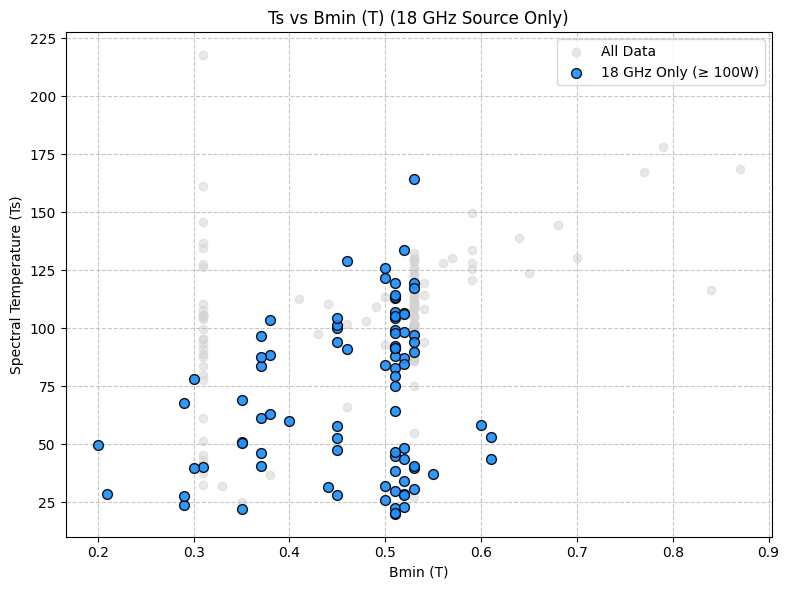

Plot successfully generated with 88 isolated points.


In [ ]:
#Ts vs Bmin (Dual-Layer Plot for 18 GHz Only)

# 2. Drop rows missing the required data for plotting
df_clean = realTs.dropna(subset=['spectral_temperature', '14 GHz', '18 GHz', '28 GHz']).copy()

# 3. Apply the 50 W threshold logic for "ONLY 18 GHz"
# 18 GHz must be >= 50 W, while 14 GHz and 28 GHz must be < 50 W
only_18_filter = (
    (df_clean['18 GHz'] >= 50) & 
    (df_clean['14 GHz'] < 50) & 
    (df_clean['28 GHz'] < 50)
)
df_18_only = df_clean[only_18_filter]

# 4. Generate the Dual-Layer Plot
if len(df_18_only) > 0:
    plt.figure(figsize=(8, 6))
    
    # PLOT 1 (BACKGROUND): All Cleaned Data
    plt.scatter(df_clean['Cent (T)'], df_clean['spectral_temperature'], 
                color='lightgray', alpha=0.5, label='All Data', zorder=1)
    
    # PLOT 2 (FOREGROUND): Only 18 GHz active
    plt.scatter(df_18_only['Cent (T)'], df_18_only['spectral_temperature'], 
                color='dodgerblue', edgecolor='k', alpha=0.9, s=50, 
                label='18 GHz Only (\u2265 100W)', zorder=2)
    
    plt.xlabel('Bmin (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs ' + 'Bmin (T)' + ' (18 GHz Source Only)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add a legend
    plt.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_18_only)} isolated points.")
else:
    print("No valid data points found where ONLY the 18 GHz source was active.")

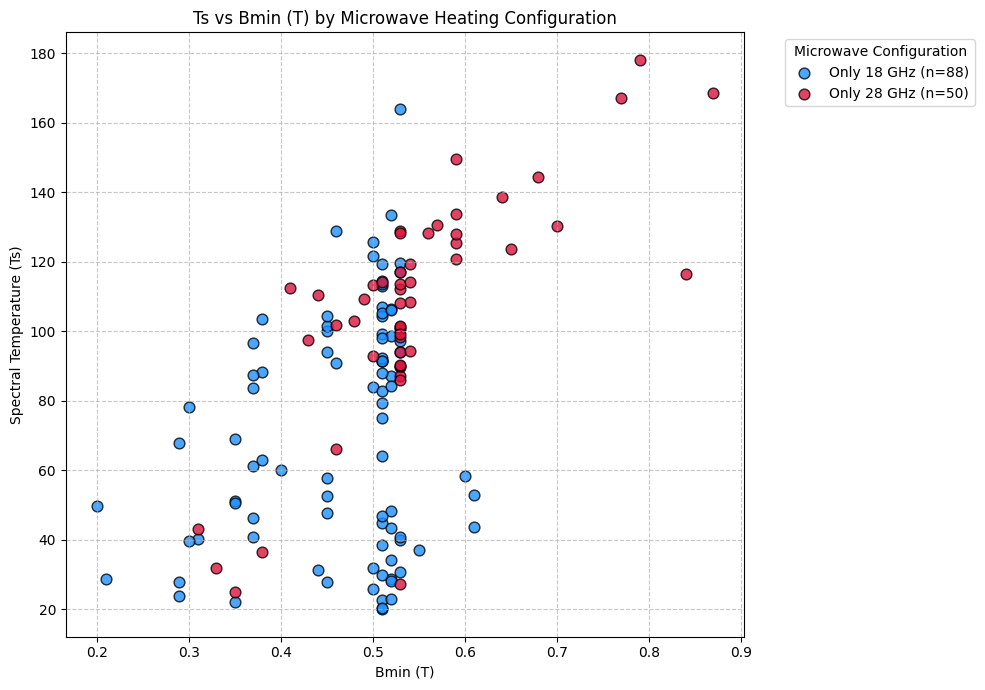

In [ ]:
#Ts vs Heating Frequencies

# 1. Drop rows missing the primary plotting variables
df_plot = realTs.dropna(subset=['spectral_temperature', 'Cent (T)']).copy()

# 3. Create base conditions: "Active" (>= 50W) and "Inactive" (< 50W)
act_14 = df_plot['14 GHz'] >= 50
act_18 = df_plot['18 GHz'] >= 50
act_28 = df_plot['28 GHz'] >= 50

inact_14 = df_plot['14 GHz'] < 50
inact_18 = df_plot['18 GHz'] < 50
inact_28 = df_plot['28 GHz'] < 50

# 4. Define the 5 specific heating combinations
cond_18_only = inact_14 & act_18 & inact_28
cond_28_only = inact_14 & inact_18 & act_28
cond_18_28   = inact_14 & act_18 & act_28
cond_14_18   = act_14 & act_18 & inact_28
cond_all_3   = act_14 & act_18 & act_28

# 5. Extract the subsets based on those conditions
df_18_only = df_plot[cond_18_only]
df_28_only = df_plot[cond_28_only]
df_18_28   = df_plot[cond_18_28]
df_14_18   = df_plot[cond_14_18]
df_all_3   = df_plot[cond_all_3]

# 6. Generate the Multi-Layer Plot
plt.figure(figsize=(10, 7))

# Plot each subset with a distinct color, black edge, and standard sizing
plt.scatter(df_18_only['Cent (T)'], df_18_only['spectral_temperature'], 
            color='dodgerblue', s=60, edgecolor='k', alpha=0.8, label=f'Only 18 GHz (n={len(df_18_only)})')

plt.scatter(df_28_only['Cent (T)'], df_28_only['spectral_temperature'], 
            color='crimson', s=60, edgecolor='k', alpha=0.8, label=f'Only 28 GHz (n={len(df_28_only)})')

#plt.scatter(df_18_28['Cent (T)'], df_18_28['spectral_temperature'], 
            #color='mediumpurple', s=60, edgecolor='k', alpha=0.8, label=f'18 + 28 GHz (n={len(df_18_28)})')

#plt.scatter(df_14_18['Cent (T)'], df_14_18['spectral_temperature'], 
            #color='darkorange', s=60, edgecolor='k', alpha=0.8, label=f'14 + 18 GHz (n={len(df_14_18)})')

#plt.scatter(df_all_3['Cent (T)'], df_all_3['spectral_temperature'], 
            #color='forestgreen', s=60, edgecolor='k', alpha=0.8, label=f'14 + 18 + 28 GHz (n={len(df_all_3)})')

# Formatting
plt.xlabel('Bmin (T)')
plt.ylabel('Spectral Temperature (Ts)')
plt.title('Ts vs Bmin (T) by Microwave Heating Configuration')
plt.grid(True, linestyle='--', alpha=0.7)

# Move the legend outside the plot area so it doesn't cover your data
plt.legend(title='Microwave Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
#Ts vs 14 GHz Only (no data)

# Drop any rows where we don't have Spectral Temperature or Bmin
df_plot = realTs.dropna(subset=['spectral_temperature', 'Cent (T)'])

# 2. Filter for ONLY 14 GHz active (assuming >100W means active)
cond_14 = df_plot['14 GHz'].notna() | (df_plot['14 GHz'] >= 100)
cond_18 = df_plot['18 GHz'].isna() | (df_plot['18 GHz'] < 100)
cond_28 = df_plot['28 GHz'].isna() & (df_plot['28 GHz'] < 100)

df_14only = df_plot[cond_14 & cond_18 & cond_28]

print(f"Data points matching 14 only criteria: {len(df_14only)}")

# 3. Generate the Plot
if len(df_14only) > 0:
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(df_14only['Cent (T)'], df_14only['spectral_temperature'], 
                     c=df_14only['14 GHz'], cmap='plasma', s=60, edgecolor='k')
    
    plt.xlabel('Bmin (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs Bmin (14 GHz Power Only)')
    plt.colorbar(sc, label='14 GHz Power (W)')
    plt.grid(True, linestyle='--', alpha=0.7)

else:
    print("No rows found where 14 GHz was the ONLY active power source.")

Data points matching 14 only criteria: 0
No rows found where 14 GHz was the ONLY active power source.


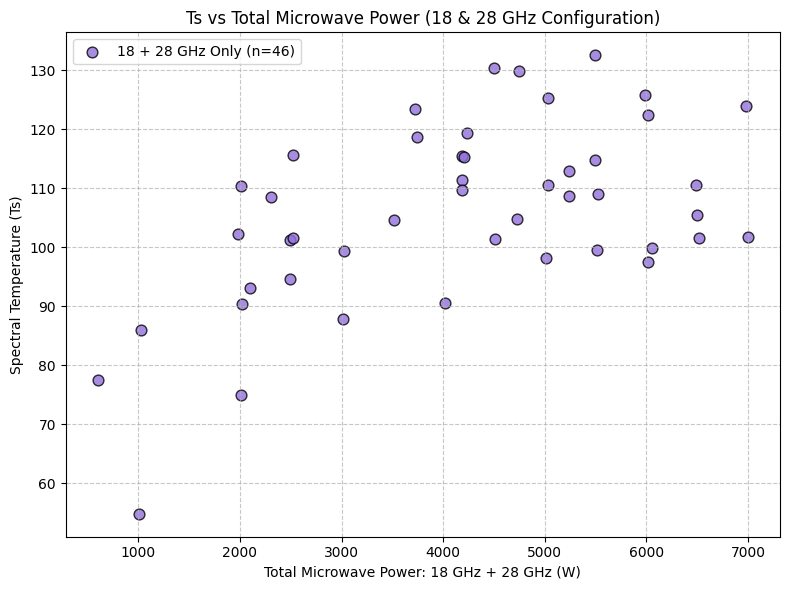

Plot successfully generated with 46 points.


In [25]:
#Ts vs Total Microwave Power (18 & 28 GHz Configuration)

# Adjust column names if they differ slightly in your active dataset
df_plot = realTs.dropna(subset=['spectral_temperature', '14 GHz', '18 GHz', '28 GHz'], how='all').copy()

# 3. Filter for ONLY 18 GHz and 28 GHz active
# 18 and 28 must be >= 50 W, while 14 must be < 50 W
cond_14_off = df_plot['14 GHz'] < 50
cond_18_on  = df_plot['18 GHz'] >= 50
cond_28_on  = df_plot['28 GHz'] >= 50

df_18_28_only = df_plot[cond_14_off & cond_18_on & cond_28_on].copy()

# 4. Calculate Total Power for the x-axis
df_18_28_only['Total_Power (W)'] = df_18_28_only['18 GHz'] + df_18_28_only['28 GHz']

# 5. Generate the Plot
if len(df_18_28_only) > 0:
    plt.figure(figsize=(8, 6))
    
    plt.scatter(df_18_28_only['Total_Power (W)'], df_18_28_only['spectral_temperature'], 
                color='mediumpurple', s=60, edgecolor='k', alpha=0.8, 
                label=f'18 + 28 GHz Only (n={len(df_18_28_only)})')
    
    # Formatting
    plt.xlabel('Total Microwave Power: 18 GHz + 28 GHz (W)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs Total Microwave Power (18 & 28 GHz Configuration)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_18_28_only)} points.")
else:
    print("No valid data points found where exactly 18 GHz and 28 GHz were active.")

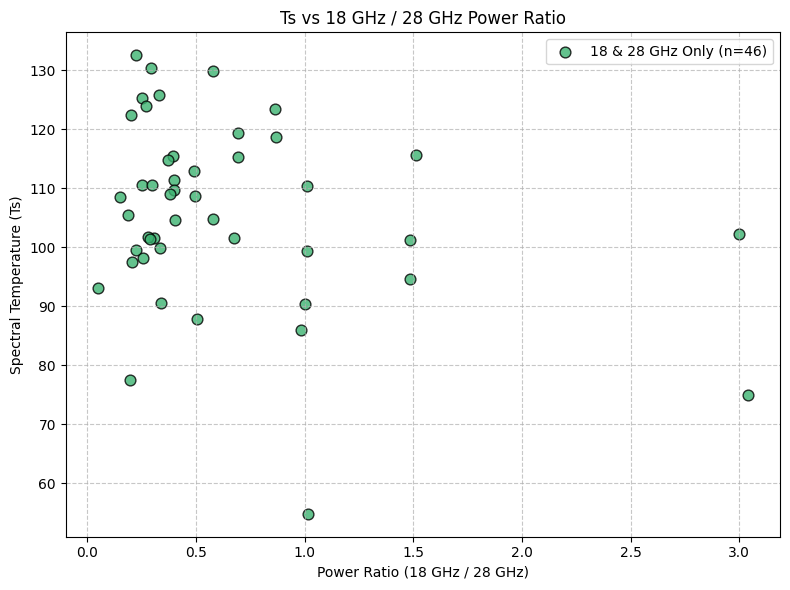

Plot successfully generated with 46 points.


In [26]:
#Ts vs Power Ratio (18 GHz / 28 GHz)

# 3. Filter for ONLY 18 GHz and 28 GHz active
# 18 and 28 must be >= 50 W, while 14 must be < 50 W
cond_14_off = df_plot['14 GHz'] < 50
cond_18_on  = df_plot['18 GHz'] >= 50
cond_28_on  = df_plot['28 GHz'] >= 50

df_18_28_only = df_plot[cond_14_off & cond_18_on & cond_28_on].copy()

# 4. Calculate the Power Ratio for the x-axis (18 GHz / 28 GHz)
df_18_28_only['Power_Ratio_18_28'] = df_18_28_only['18 GHz'] / df_18_28_only['28 GHz']

# 5. Generate the Plot
if len(df_18_28_only) > 0:
    plt.figure(figsize=(8, 6))
    
    plt.scatter(df_18_28_only['Power_Ratio_18_28'], df_18_28_only['spectral_temperature'], 
                color='mediumseagreen', s=60, edgecolor='k', alpha=0.8, 
                label=f'18 & 28 GHz Only (n={len(df_18_28_only)})')
    
    # Formatting
    plt.xlabel('Power Ratio (18 GHz / 28 GHz)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs 18 GHz / 28 GHz Power Ratio')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_18_28_only)} points.")
else:
    print("No valid data points found where exactly 18 GHz and 28 GHz were active.")

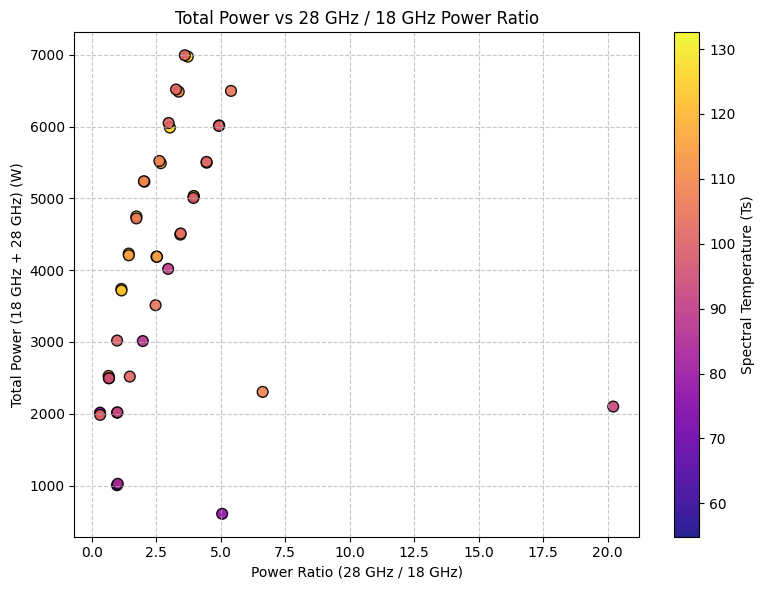

Plot successfully generated with 46 points.


In [32]:
# 3. Filter for ONLY 18 GHz and 28 GHz active
# 18 and 28 must be >= 50 W, while 14 must be < 50 W
cond_14_off = df_plot['14 GHz'] < 50
cond_18_on  = df_plot['18 GHz'] >= 50
cond_28_on  = df_plot['28 GHz'] >= 50

df_18_28_only = df_plot[cond_14_off & cond_18_on & cond_28_on].copy()

# 4. Calculate Total Power and the New Power Ratio (28 GHz / 18 GHz)
df_18_28_only['Total_Power'] = df_18_28_only['18 GHz'] + df_18_28_only['28 GHz']
df_18_28_only['Power_Ratio_28_18'] = df_18_28_only['28 GHz'] / df_18_28_only['18 GHz']

# 5. Generate the Plot
if len(df_18_28_only) > 0:
    plt.figure(figsize=(8, 6))
    
    # Plot Scatter with Ts mapped to color
    sc = plt.scatter(df_18_28_only['Power_Ratio_28_18'], 
                     df_18_28_only['Total_Power'], 
                     c=df_18_28_only['spectral_temperature'], 
                     cmap='plasma', s=60, edgecolor='k', alpha=0.9)
    
    # Formatting
    plt.xlabel('Power Ratio (28 GHz / 18 GHz)')
    plt.ylabel('Total Power (18 GHz + 28 GHz) (W)')
    plt.title('Total Power vs 28 GHz / 18 GHz Power Ratio')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add color bar for Spectral Temperature
    plt.colorbar(sc, label='Spectral Temperature (Ts)')
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_18_28_only)} points.")
else:
    print("No valid data points found where exactly 18 GHz and 28 GHz were active.")

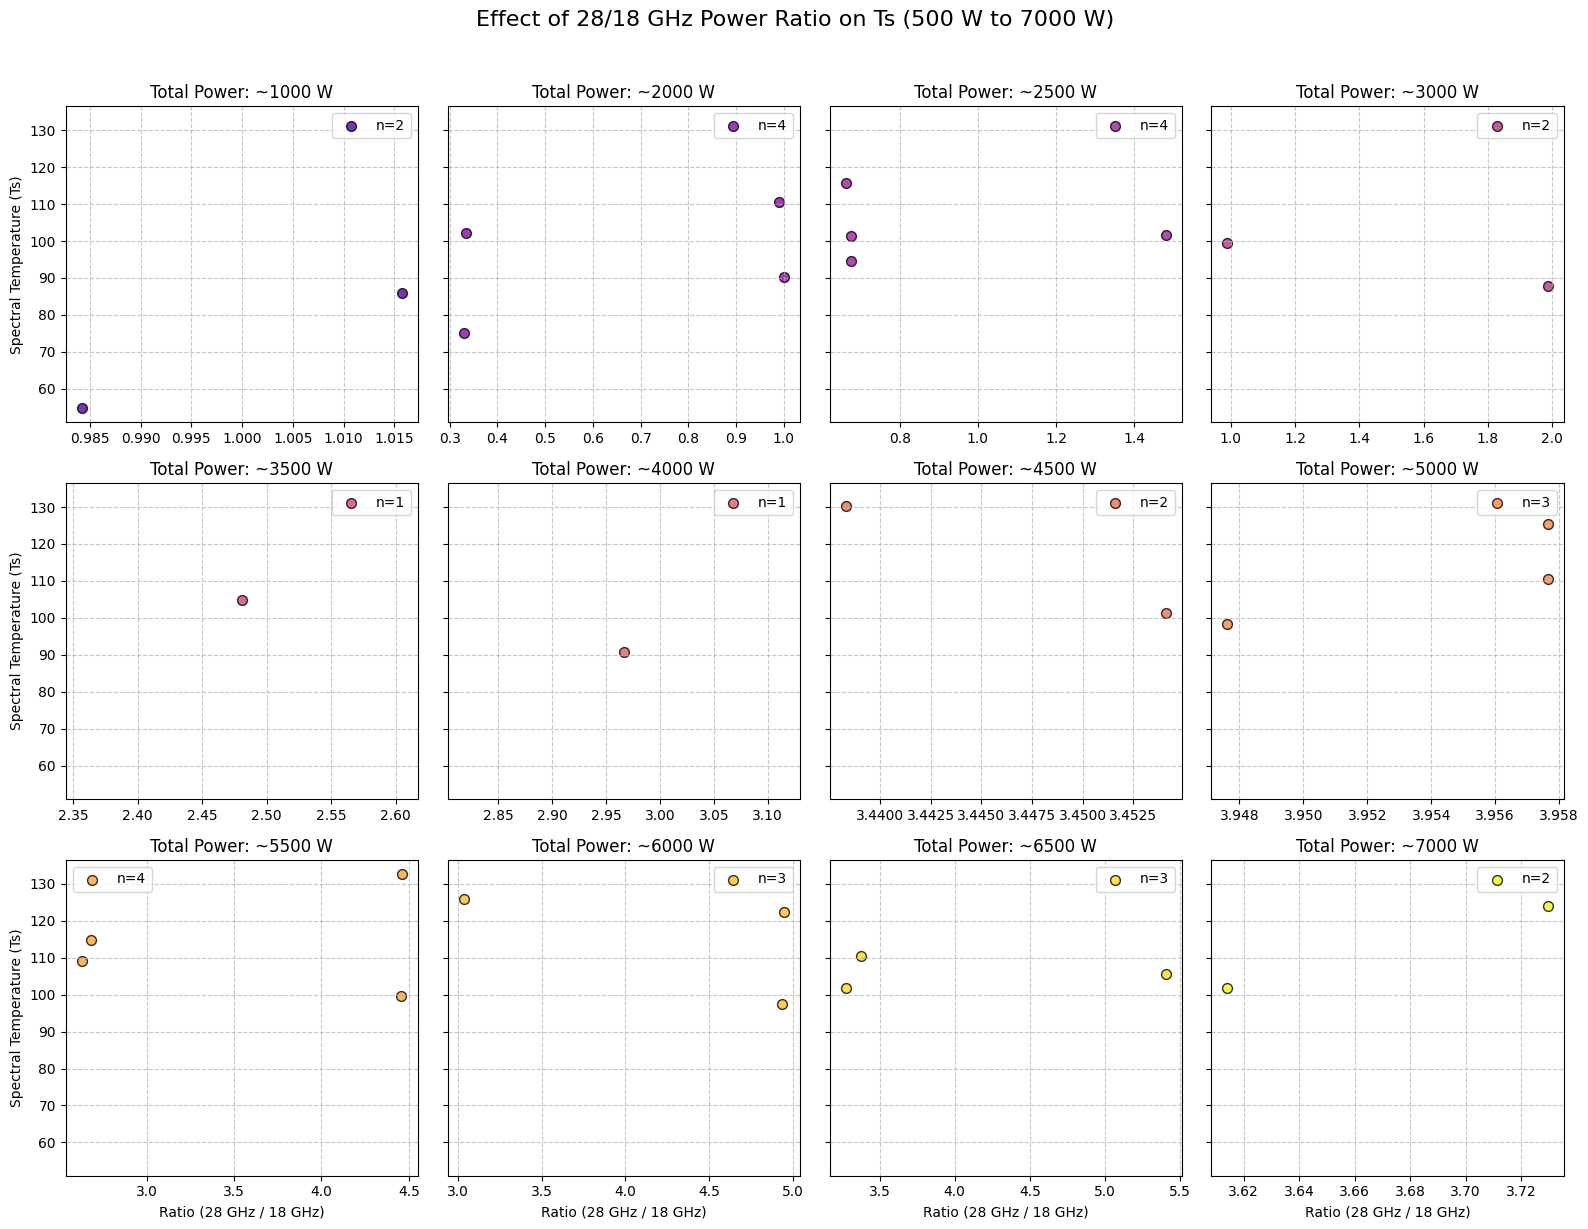

In [37]:
# 1. Filter for ONLY 18 GHz and 28 GHz active
cond_14_off = df_plot['14 GHz'] < 50
cond_18_on  = df_plot['18 GHz'] >= 50
cond_28_on  = df_plot['28 GHz'] >= 50

df_18_28_only = df_plot[cond_14_off & cond_18_on & cond_28_on].copy()

# 2. Calculate Total Power and Power Ratio
df_18_28_only['Total_Power'] = df_18_28_only['18 GHz'] + df_18_28_only['28 GHz']
df_18_28_only['Power_Ratio_28_18'] = df_18_28_only['28 GHz'] / df_18_28_only['18 GHz']

# 3. Define bin targets and tolerance
# This generates a list: [500, 1000, 1500, ..., 7000]
targets = range(500, 7501, 500)
tolerance = 50  # +/- 50 W (Increase this if higher-power runs had more variance)

# 4. Gather only the bins that actually contain data
valid_bins = []
for target in targets:
    mask = (df_18_28_only['Total_Power'] >= (target - tolerance)) & (df_18_28_only['Total_Power'] <= (target + tolerance))
    subset = df_18_28_only[mask]
    if not subset.empty:
        valid_bins.append((target, subset))

# 5. Generate the Plot Grid
if len(valid_bins) > 0:
    # Calculate grid dimensions (max 4 columns wide)
    ncols = min(4, len(valid_bins))
    nrows = math.ceil(len(valid_bins) / ncols)
    
    # sharey=True locks the Y-axis so Ts scales identically across all plots
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), sharey=True)
    
    # Ensure axes is a flat array even if it's 1D or a single plot
    axes = np.array(axes).flatten()
    
    # Use a colormap to automatically color code from low to high power
    cmap = plt.get_cmap('plasma')
    
    # Loop through our valid data and plot
    for i, (target, subset) in enumerate(valid_bins):
        ax = axes[i]
        
        # Map the color smoothly along the colormap based on the target power
        color = cmap(target / 7000)
        
        ax.scatter(subset['Power_Ratio_28_18'], subset['spectral_temperature'], 
                   color=color, s=50, edgecolor='k', alpha=0.8,
                   label=f'n={len(subset)}')
        
        ax.set_title(f'Total Power: ~{target} W')
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(loc='best')
        
        # Add X-axis label to the bottom row of plots
        if i >= len(valid_bins) - ncols:
            ax.set_xlabel('Ratio (28 GHz / 18 GHz)')
            
        # Add Y-axis label to the first column of plots
        if i % ncols == 0:
            ax.set_ylabel('Spectral Temperature (Ts)')

    # Hide any extra empty subplots (e.g., if you have 10 valid bins in a 3x4 grid)
    for j in range(len(valid_bins), len(axes)):
        axes[j].set_visible(False)
        
    fig.suptitle('Effect of 28/18 GHz Power Ratio on Ts (500 W to 7000 W)', fontsize=16, y=1.02)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No data points found matching the specified power bins.")

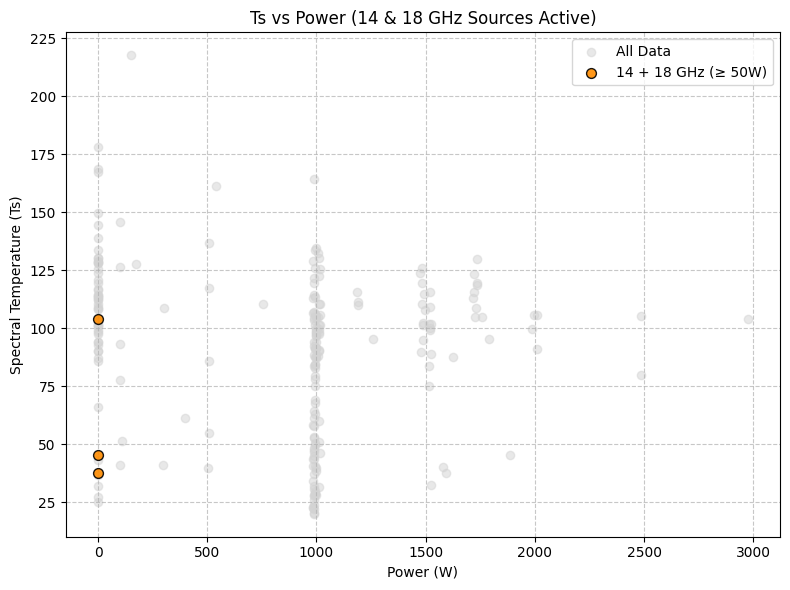

Plot successfully generated with 3 isolated points.


In [18]:
# Ensure the datetime column is properly formatted
realTs['datetime'] = pd.to_datetime(realTs['datetime'])

# 2. Drop rows missing the required data for plotting (exclude power columns here)
df_clean = realTs.dropna(subset=['spectral_temperature', 'Cent (T)']).copy()

# 4. Apply the threshold logic for "14 GHz AND 18 GHz"
# 14 GHz and 18 GHz must be >= 50 W, while 28 GHz must be < 50 W
dual_14_18_filter = (
    (df_clean['14 GHz'] >= 50) & 
    (df_clean['18 GHz'] >= 50) & 
    (df_clean['28 GHz'] < 50)
)
df_14_18 = df_clean[dual_14_18_filter]

# 5. Generate the Dual-Layer Plot
if len(df_14_18) > 0:
    plt.figure(figsize=(8, 6))
    
    # PLOT 1 (BACKGROUND): All Cleaned Data
    plt.scatter(df_clean['14 GHz'] + df_clean['18 GHz'], df_clean['spectral_temperature'], 
                color='lightgray', alpha=0.5, label='All Data', zorder=1)
    
    # PLOT 2 (FOREGROUND): 14 GHz + 18 GHz active
    plt.scatter(df_14_18['Cent (T)'], df_14_18['spectral_temperature'], 
                color='darkorange', edgecolor='k', alpha=0.9, s=50, 
                label='14 + 18 GHz (\u2265 50W)', zorder=2)
    
    plt.xlabel('Power (W)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs ' + 'Power' + ' (14 & 18 GHz Sources Active)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add a legend
    plt.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_14_18)} isolated points.")
else:
    print("No valid data points found where exactly 14 & 18 GHz sources were active.")

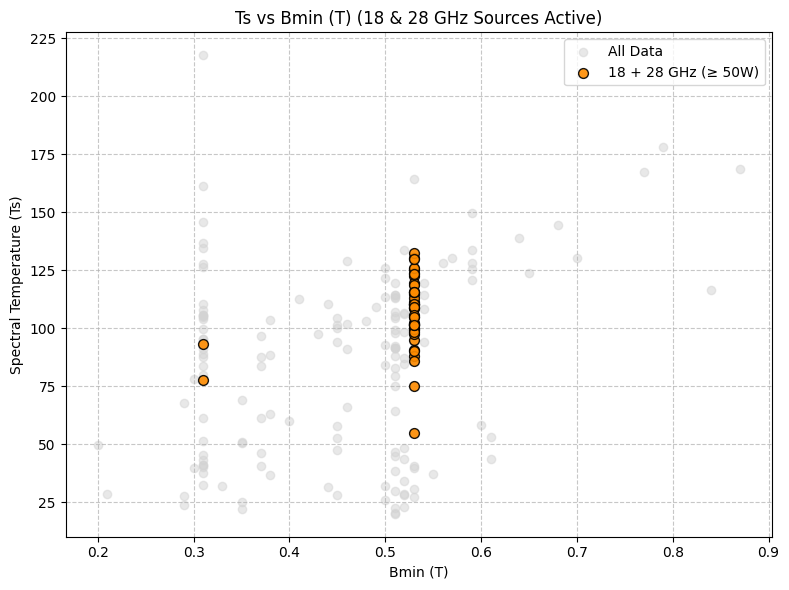

Plot successfully generated with 46 isolated points.


In [13]:
# Ensure the datetime column is properly formatted
realTs['datetime'] = pd.to_datetime(realTs['datetime'])

# 2. Drop rows missing the required data for plotting (exclude power columns here)
df_clean = realTs.dropna(subset=['spectral_temperature', 'Cent (T)']).copy()

# 4. Apply the threshold logic for "18 GHz AND 28 GHz"
# 18 GHz and 28 GHz must be >= 50 W, while 14 GHz must be < 50 W
dual_18_28_filter = (
    (df_clean['18 GHz'] >= 50) & 
    (df_clean['28 GHz'] >= 50) &
    (df_clean['14 GHz'] < 50)
)
df_18_28 = df_clean[dual_18_28_filter]

# 5. Generate the Dual-Layer Plot
if len(df_18_28) > 0:
    plt.figure(figsize=(8, 6))
    
    # PLOT 1 (BACKGROUND): All Cleaned Data
    plt.scatter(df_clean['Cent (T)'], df_clean['spectral_temperature'], 
                color='lightgray', alpha=0.5, label='All Data', zorder=1)
    
    # PLOT 2 (FOREGROUND): 18 GHz + 28 GHz active
    plt.scatter(df_18_28['Cent (T)'], df_18_28['spectral_temperature'], 
                color='darkorange', edgecolor='k', alpha=0.9, s=50, 
                label='18 + 28 GHz (\u2265 50W)', zorder=2)
    
    plt.xlabel('Bmin (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs ' + 'Bmin (T)' + ' (18 & 28 GHz Sources Active)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add a legend
    plt.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_18_28)} isolated points.")
else:
    print("No valid data points found where exactly 18 & 28 GHz sources were active.")

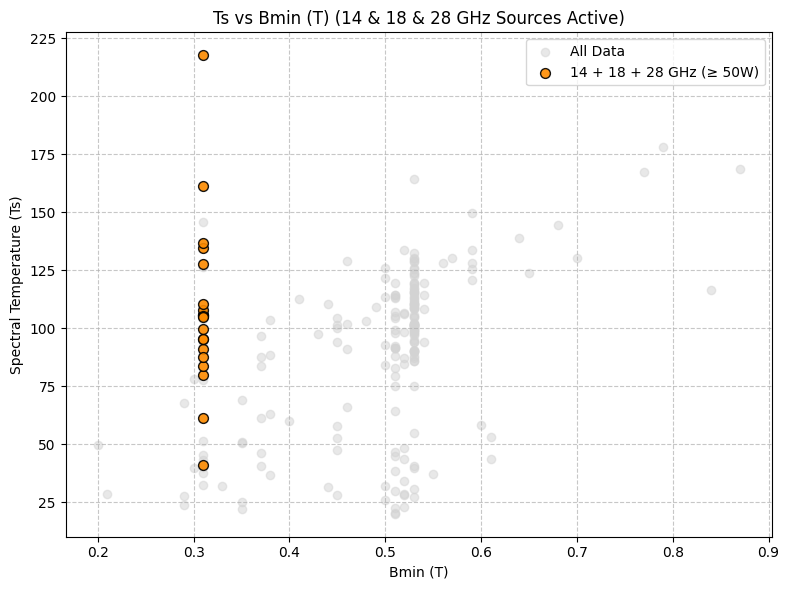

Plot successfully generated with 20 isolated points.


In [16]:
# Ensure the datetime column is properly formatted
realTs['datetime'] = pd.to_datetime(realTs['datetime'])

# 2. Drop rows missing the required data for plotting (exclude power columns here)
df_clean = realTs.dropna(subset=['spectral_temperature', 'Cent (T)']).copy()

# 4. Apply the threshold logic for "14 GHz AND 18 GHz AND 28 GHz"
# 14 GHz and 18 GHz must be >= 50 W, while 28 GHz must be < 50 W
dual_14_18_28_filter = (
    (df_clean['14 GHz'] >= 50) & 
    (df_clean['18 GHz'] >= 50) & 
    (df_clean['28 GHz'] >= 50)
)
df_14_18_28 = df_clean[dual_14_18_28_filter]

# 5. Generate the Dual-Layer Plot
if len(df_14_18_28) > 0:
    plt.figure(figsize=(8, 6))
    
    # PLOT 1 (BACKGROUND): All Cleaned Data
    plt.scatter(df_clean['Cent (T)'], df_clean['spectral_temperature'], 
                color='lightgray', alpha=0.5, label='All Data', zorder=1)
    
    # PLOT 2 (FOREGROUND): 14 GHz + 18 GHz + 28 GHz active
    plt.scatter(df_14_18_28['Cent (T)'], df_14_18_28['spectral_temperature'], 
                color='darkorange', edgecolor='k', alpha=0.9, s=50, 
                label='14 + 18 + 28 GHz (\u2265 50W)', zorder=2)
    
    plt.xlabel('Bmin (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs ' + 'Bmin (T)' + ' (14 & 18 & 28 GHz Sources Active)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add a legend
    plt.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_14_18_28)} isolated points.")
else:
    print("No valid data points found where exactly 14 & 18 GHz sources were active.")

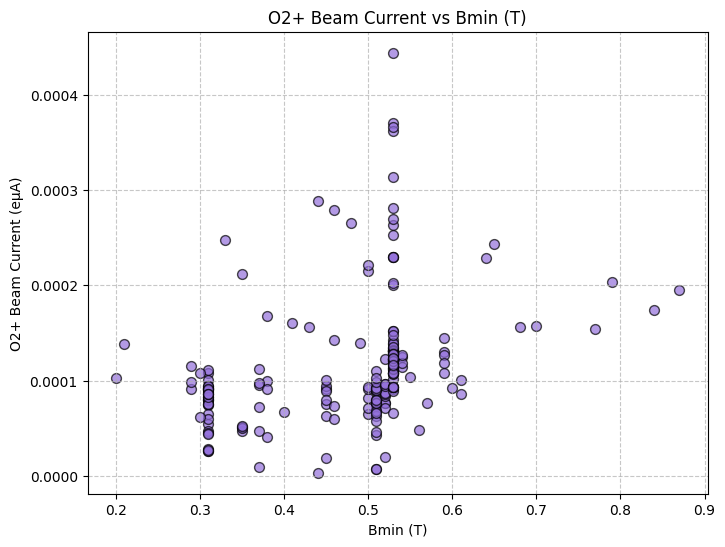

Plot successfully generated with 213 points.


In [146]:
# Define the exact columns you want to plot
x_col = 'Cent (T)'
y_col = 'O2+_beam_current'

# Drop rows that are missing data for either Cent (T) or O2+
df_plot = realTs.dropna(subset=[x_col, y_col]).copy()

# Generate the plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # Create the scatter plot
    plt.scatter(df_plot[x_col], df_plot[y_col], 
                color='mediumpurple', alpha=0.7, edgecolor='k', s=50)
    
    # Formatting
    plt.xlabel('Bmin (T)')
    plt.ylabel('O2+ Beam Current (eμA)')
    plt.title('O2+ Beam Current vs Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found for O2+ and Bmin (T).")

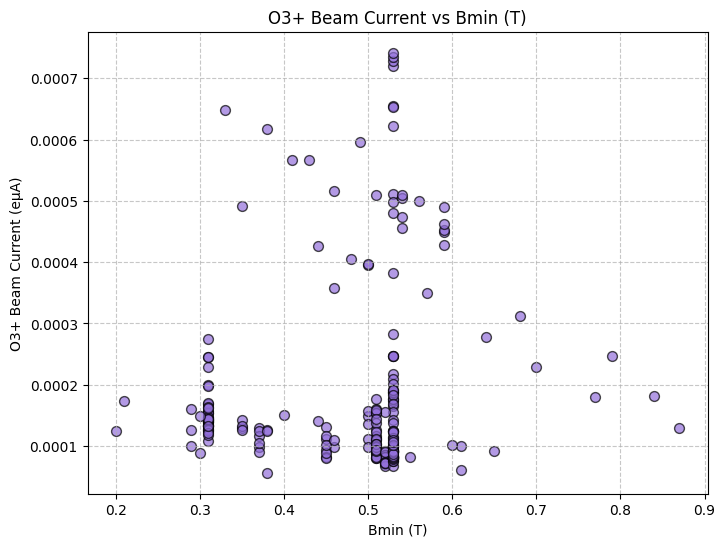

Plot successfully generated with 213 points.


In [147]:
# Define the exact columns you want to plot
x_col = 'Cent (T)'
y_col = 'O3+_beam_current'

# Drop rows that are missing data for either Cent (T) or O3+
df_plot = realTs.dropna(subset=[x_col, y_col]).copy()

# Generate the plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # Create the scatter plot
    plt.scatter(df_plot[x_col], df_plot[y_col], 
                color='mediumpurple', alpha=0.7, edgecolor='k', s=50)
    
    # Formatting
    plt.xlabel('Bmin (T)')
    plt.ylabel('O3+ Beam Current (eμA)')
    plt.title('O3+ Beam Current vs Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found for O3+ and Bmin (T).")

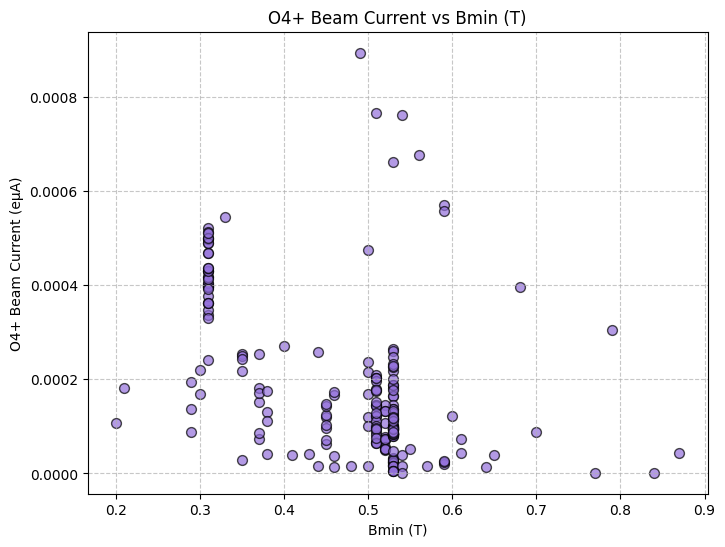

Plot successfully generated with 213 points.


In [148]:
# Define the exact columns you want to plot
x_col = 'Cent (T)'
y_col = 'O4+_beam_current'

# Drop rows that are missing data for either Cent (T) or O4+
df_plot = realTs.dropna(subset=[x_col, y_col]).copy()

# Generate the plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # Create the scatter plot
    plt.scatter(df_plot[x_col], df_plot[y_col], 
                color='mediumpurple', alpha=0.7, edgecolor='k', s=50)
    
    # Formatting
    plt.xlabel('Bmin (T)')
    plt.ylabel('O4+ Beam Current (eμA)')
    plt.title('O4+ Beam Current vs Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found for O4+ and Bmin (T).")

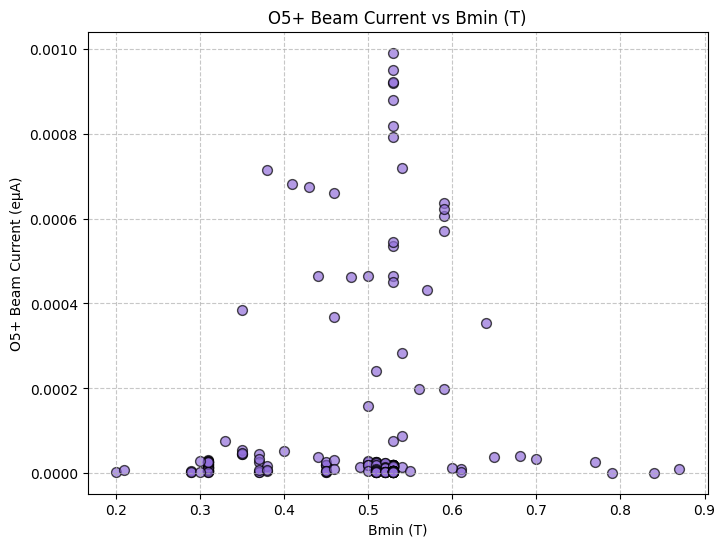

Plot successfully generated with 213 points.


In [149]:
# Define the exact columns you want to plot
x_col = 'Cent (T)'
y_col = 'O5+_beam_current'

# Drop rows that are missing data for either Cent (T) or O5+
df_plot = realTs.dropna(subset=[x_col, y_col]).copy()

# Generate the plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # Create the scatter plot
    plt.scatter(df_plot[x_col], df_plot[y_col], 
                color='mediumpurple', alpha=0.7, edgecolor='k', s=50)
    
    # Formatting
    plt.xlabel('Bmin (T)')
    plt.ylabel('O5+ Beam Current (eμA)')
    plt.title('O5+ Beam Current vs Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found for O5+ and Bmin (T).")

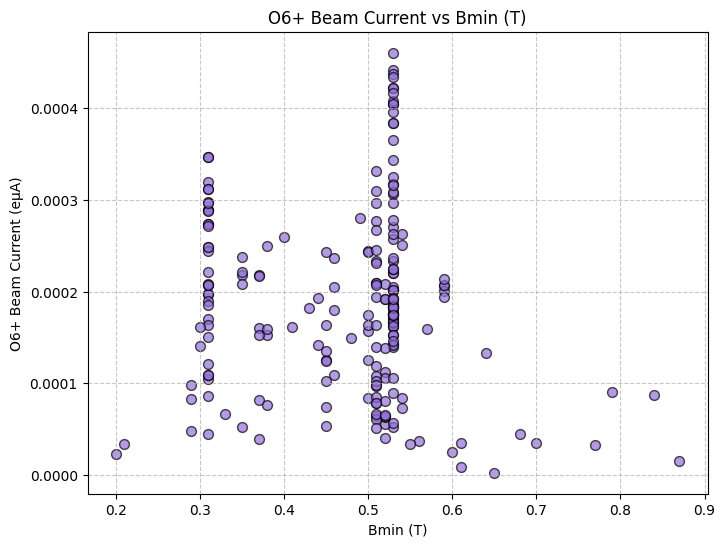

Plot successfully generated with 213 points.


In [150]:
# Define the exact columns you want to plot
x_col = 'Cent (T)'
y_col = 'O6+_beam_current'

# Drop rows that are missing data for either Cent (T) or O6+
df_plot = realTs.dropna(subset=[x_col, y_col]).copy()

# Generate the plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # Create the scatter plot
    plt.scatter(df_plot[x_col], df_plot[y_col], 
                color='mediumpurple', alpha=0.7, edgecolor='k', s=50)
    
    # Formatting
    plt.xlabel('Bmin (T)')
    plt.ylabel('O6+ Beam Current (eμA)')
    plt.title('O6+ Beam Current vs Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found for O6+ and Bmin (T).")

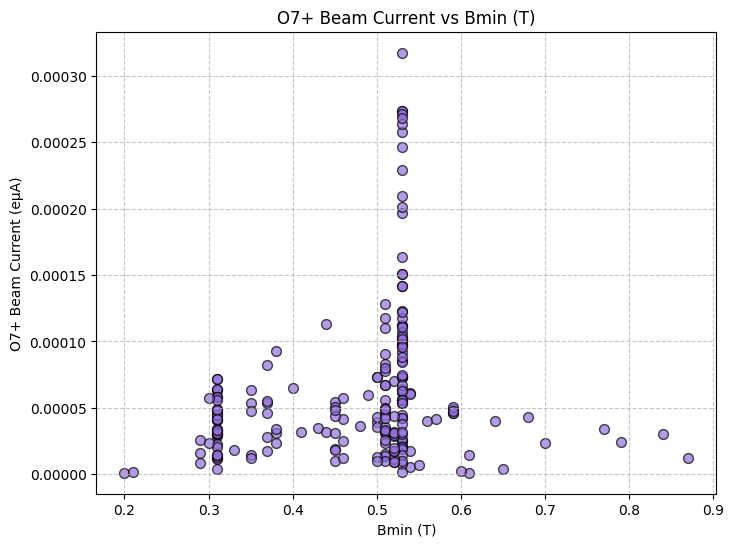

Plot successfully generated with 213 points.


In [151]:
# Define the exact columns you want to plot
x_col = 'Cent (T)'
y_col = 'O7+_beam_current'

# Drop rows that are missing data for either Cent (T) or O7+
df_plot = realTs.dropna(subset=[x_col, y_col]).copy()

# Generate the plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # Create the scatter plot
    plt.scatter(df_plot[x_col], df_plot[y_col], 
                color='mediumpurple', alpha=0.7, edgecolor='k', s=50)
    
    # Formatting
    plt.xlabel('Bmin (T)')
    plt.ylabel('O7+ Beam Current (eμA)')
    plt.title('O7+ Beam Current vs Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found for O7+ and Bmin (T).")

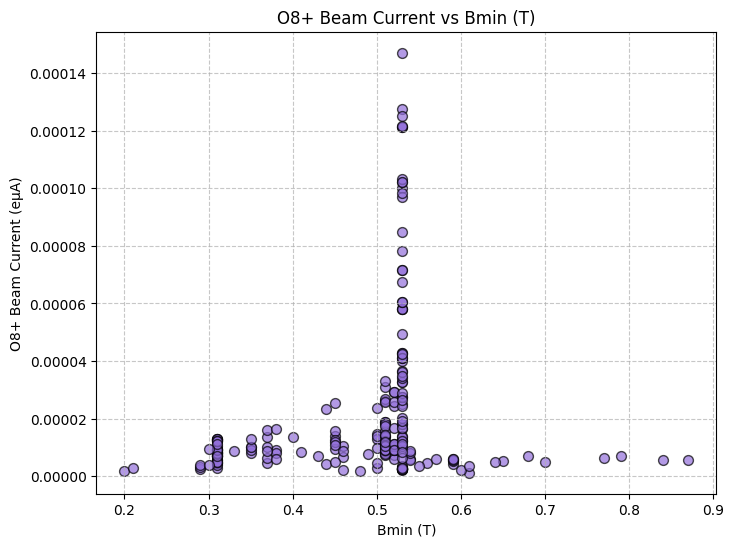

Plot successfully generated with 213 points.


In [152]:
# Define the exact columns you want to plot
x_col = 'Cent (T)'
y_col = 'O8+_beam_current'

# Drop rows that are missing data for either Cent (T) or O8+
df_plot = realTs.dropna(subset=[x_col, y_col]).copy()

# Generate the plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # Create the scatter plot
    plt.scatter(df_plot[x_col], df_plot[y_col], 
                color='mediumpurple', alpha=0.7, edgecolor='k', s=50)
    
    # Formatting
    plt.xlabel('Bmin (T)')
    plt.ylabel('O8+ Beam Current (eμA)')
    plt.title('O8+ Beam Current vs Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found for O8+ and Bmin (T).")